![Bildquelle: JFL Photography/stock.adobe.com](stadthaus_fraumuenster_zuerich.jpg)

# Offene Gebäudedaten der Schweiz nutzen

**Die Schweiz verfügt mit dem nationalen Gebäude- und Wohnungsregister (GWR) über ein weltweit einzigartiges System. Das GWR beinhaltet aktuelle Daten über alle Gebäude und Wohnungen in der gesamten Schweiz. Damit kann die Bautätigkeit über das gesamte Land beobachtet, untersucht und zwischen den einzelnen Regionen verglichen werden. Es lassen sich vielfältige Rückschlüsse über den Zustand und die Qualität des nationalen Gebäude- und Wohnungsbestands ziehen und bei Bedarf entsprechende wirtschaftspolitische Massnahmen erarbeiten. Aber wie können auch Sie als technisch interessierter Bürger vom GWR profitieren?**

Das GWR ist ein ambitioniertes Unterfangen. In der Schweiz ist es gelungen, ein Gebäude- und Wohnungsregister auf nationaler Ebene einzuführen und zu pflegen. Grundsätzlich ist so ein GWR eine tolle Sache, denn es bietet die Datengrundlage, um nachhaltige strategische Entscheidungen für die Baubranche treffen zu können.

In diesem Workshop wollen wir an den öffentlichen Webservice der GWR-Daten und an dessen Geodaten explorativ herangehen und anschliessend mit typischen Data-Science-Werkzeugen wie Jupyter Notebook und der `pandas`-Bibliothek eine einfache statistische Untersuchung auf den Daten durchführen. Zum Mitmachen bei diesem Workshop sind nur ganz grundlegende Kenntnisse in der interpretierten Programmiersprache Python und dem kompakten Datenformat JSON notwendig.

## Die Technologie des Gebäude- und Wohnungsregisters

Bevor wir zum praktischen Teil kommen, schauen wir uns doch zunächst kurz an, welche technische Infrastruktur hinter dem GWR steckt. Die Bestandteile sind offen spezifiziert, die Normen werden vom Schweizer Digital-Verein "eCH" publiziert. Beim Blick in die Spezifikationen ist festzustellen, dass das GWR über Webservices vom eidgenössischen Bundesamt für Statistik (BfS) bereitgestellt wird. Relevant sind hierbei insbesondere die beiden eCH-Normen _eCH 0206_: "GWR-Daten an Dritte" (für "read only services") und _eCH 0216_: "GWR-Nachführung" (für "read/write services"). In beiden Normen wird

* HTTP-REST als Dienste-Technologie und
* XML als Format für den Datenaustausch definiert.

Die XML-Formate sind technisch detailliert spezifiziert in den entsprechenden XML Schema-Definitionen (XSD). Auch die XSDs sind offengelegt und können hier heruntergeladen werden:

* XSD für _eCH 0206_: <https://www.ech.ch/de/dokument/3408d1dd-ec15-4af0-ab3a-62b6eb2cb29d>
* XSD für _eCH 0216_: <https://ech.ch/de/dokument/9925cecb-f0f3-4aaa-8588-93cdee453f14>

Mit Hilfe der XSDs ist es möglich, die XML-Instanzen automatisiert zu validieren. Die XSD wiederum setzen technisch präzise das um, was im sog. "Merkmalskatalog" (MMK) des GWR in Prosa beschrieben wird. Der MMK enthält also Beschreibungen zu den Objekten, die im GWR modelliert werden können, und deren zulässigen Attributen. Die aktuelle Version des MMK ist die Version 4.1, sie kann hier kostenfrei heruntergeladen werden:

* MMK 4.1: <https://www.bfs.admin.ch/bfs/de/home/statistiken/kataloge-datenbanken/publikationen.assetdetail.7008785.html>

Mit MMK 4.1 lassen sich nicht nur Gebäude modellieren, sondern ebenso

* Wohnungen,
* Eingänge,
* Strassen,
* Bauprojekte und
* (Bauprojekt-)Arbeiten.

Die GWR-Schnittstellen des BfS sind jedoch nicht für die allgemeine Öffentlichkeit bestimmt, sondern für Bundes-, Kantons- und Gemeindeverwaltungen. Diese Webservices ermöglichen den tagtäglichen, permanenten Datenaustausch über Gebäude und Wohnungen zwischen den Gemeinden und Kantonen der Schweiz und dem Bundesamt für Statistik.

Besonders interessant, nicht nur für die Baubranche, sind sicherlich die Daten zu den Gebäuden der Schweiz. Doch welche Eigenschaften werden an den Gebäude-Objekten im GWR grundsätzlich gepflegt? Dies können wir dem Merkmalskatalog entnehmen (siehe Link oben). Der Merkmalskatalog hilft uns genau bei dieser Frage weiter, denn er enthält eine Auflistung aller Attribute, die durch die Ämter am Gebäude erfasst werden und liefert zusätzlich auch eine detaillierte Erklärung zur Bedeutung eines jeden Attributs. Beim Durchblättern des MMK werden wir feststellen, dass für jedes Gebäude in der Schweiz bis zu ca. 40 Attribute erhoben werden. Dies sind z.B.:

* Amtliche Gebäudenummer (über die ganze Schweiz eindeutige Gebäude-ID)
* Gebäudekoordinaten (Zentroid-Punkt der Gebäudefläche auf der Erdoberfläche)
* Gebäudekategorie
* Baujahr
* etc. pp.

Wir sehen also, da gibt es einige interessante Informationen, mit denen sich Ergebnisse zu spannenden Fragestellungen erarbeiten liessen.

## Gebäude als offene Geodaten für Bürger und Wirtschaft

Aber gibt es auch für Bürger die Möglichkeit, den Output dieser Datensammlung zu nutzen? Ja, die gibt es! Das Bundesamt für Statistik hat zum Thema Gebäude- und Wohnungsregister ein Portal eingerichtet, das unter folgender Adresse zu erreichen ist:

<https://www.housing-stat.ch/>

Schon auf der Startseite des Portals:

![Startseite von housing-stat.ch](startseite_housing_stat.png)

sehen wir mittig die Einblendung einer interaktiven Online-Karte, die uns bereits die Positionen von Gebäudeeingängen anzeigt - jeder grüne Punkt repräsentiert ein bestehendes Gebäude. Dabei handelt es sich um eine Einbettung des Kartenviewers der swisstopo. Per Klick auf "In map.geo.admin.ch ansehen" öffnen wir den Kartenviewer in einem eigenen Browser-Fenster:

![GWR-Daten im Kartenviewer der swisstopo](gwr_im_kartenviewer.png)

Der Kartenviewer der swisstopo stellt diverse Geodaten der Schweiz auf einer zentralen Plattform dar, so eben auch die Daten des GWR. In unserem Fall sind die GWR-Daten für die Darstellung bereits aktiviert. Die Gebäudedaten liegen für die gesamte Schweiz vor, dies können wir gut erkennen, wenn wir einen kleinen Massstab der Karte einstellen:

![Das Bild zeigt einen Screenshot der GWR-Kartenansicht bei swisstopo, die Gebäudepunkte für die gesamte Schweiz anzeigt](gebaeude_ganze_schweiz.png)

Der Datensatz hat noch eine weitere praktische Eigenschaft. Es werden nicht nur die Positionen der Gebäudeeingänge angezeigt, wir können uns auch weitere attributive Informationen zu den Gebäuden geben lassen. Dazu müssen wir wieder einen grossen Massstab wählen und dann auf einen beliebigen grünen Punkt klicken. Es öffnen sich ein Kontext-Fenster mit Informationen zum Gebäude:

![Kontext-Fenster zeigt Informationen zu einem Gebäude](swisstopo_gwr_objektinfo.png)

Woher nimmt die Web-Applikation jedoch diese Daten, was steckt technisch dahinter? Kommen wir an die Daten auch in maschinenlesbarer Form heran und hat die Applikation vielleicht noch mehr Informationen zu den Gebäuden, die wir jetzt einfach noch gar nicht sehen?

## Der Webservice hinter der Kartenanwendung

Um das herauszufinden, untersuchen wir die WebApp im nächsten Schritt mit den F12-Tools des Browsers. In meinem Beispiel verwende ich die F12-Tools des Edge-Browsers, aber in allen anderen gängigen Browsern stehen ähnliche Funktionen als Entwicklungstools zur Verfügung. Wir drücken im Browser also die F12-Taste und öffnen die "Netzwerk"-Registerkarte. Daraufhin klicken wir einen der grünen Punkte (Gebäudemarker) in der Karte an:

![Netzwerk-Registerkarte der F12-Tools](f12_netzwerk_registerkarte.png)

In meinem Beispiel habe ich das Stadthaus in Zürich als Zentral-Gebäude gewählt. Das Netzwerkprotokoll der F12-Tools meldet uns daraufhin, dass die WebApp eine Anfrage an einen Webservice durchgeführt hat, um die einzublendenden Informationen abzuholen. Unter dem Eintrag "Anforderungs-URL" erkennen wir auch die Domainname des Webservice, diese lautet:

```
https://api3.geo.admin.ch/
```

Unter dieser Domäne läuft also der Webservice, unter dem die Rohdaten für die dargestellten Daten selbst angefragt werden. Des Weiteren erkennen wir an der Anforderungs-URL, welche Parameter verwendet werden, um die Daten abzuholen. Im Bild oben sehen wir die vollständige Anforderungs-URL, diese hat die Form (hier verkürzt dargestellt):

```
https://api3.geo.admin.ch/rest/services/all/MapServer/identify?geometry=...&tolerance=80
```

Wenn wir uns die vollständige URL genau anschauen, halten wir fest, dass folgende Parameter vorkommen können (oder müssen), um eine Webservice-Anfrage zu spezifizieren:

* `geometry` (Die Punkt-Geometrie, an der die Anfrage räumlich abgesetzt wird. Bsp.: "geometry=2561964.9000366214,1205287.7999816895")
* `geometryFormat` (Das Daten-Format, in dem die Antwort des Services kommen soll. Bsp.: "geometryFormat=geojson")
* `geometryType` (Der Geometrie-Typ, in dem die Antwort des Services kommen soll. Bsp.: "geometryType=esriGeometryPoint")
* `imageDisplay` (unbekannt, vermutlich "Bruchpixel" für Bildschirmgrössen. Kann einfach auf Standardwert belassen werden. Bsp.: "imageDisplay=915,754,96")
* `lang` (Die Sprache für die angefragten Daten. Bsp.: "lang=de")
* `layers` (Von welcher Datenebene die Daten angefragt werden. Bsp.: "layers=all:ch.bfs.gebaeude_wohnungs_register")
* `limit` (Die maximale Anzahl an Gebäude-Objekten, die zurückgeliefert werden sollen. Bsp.: "limit=10")
* `mapExtent` (Die Eck-Koordinaten des umschreibenden Rechtecks für diese Anfrage. Bsp.: "mapExtent=2561419.5,1204872.25,2562334.5,1205626.25")
* `returnGeometry` (Soll eine Geometrie bei der Antwort mitgeliefert werden? Bsp.: "returnGeometry=true")
* `sr` (Der EPSG-Code des Koordinatenbezugssystem (Spatial Reference, SR) der Anfrage. Zum Beispiel steht der EPSG-Code 2056 für das in der Schweiz übliche "LV95"-System. Bsp.: "sr=2056")
* `tolerance` (Definiert den Durchmesser des Umkreises der Anfrage in Metern um die angegebene Punkt-Geometrie herum. Bsp.: "tolerance=10")

## Ein Notizbuch für Data Science

Ab hier können wir ein Jupyter Notebook einsetzen. Jupyter Notebook hat in den letzten Jahren im Bereich der Data Science enorm an Beliebtheit gewonnen. Mit Jupyter Notebook lassen sich Online-Notizbücher erstellen, in denen sich mit Hilfe der Programmiersprache Python und der Data-Science-Bibliothek _pandas_ Daten-Analysen durchführen lassen. "Notizbuch" bedeutet hier, dass sich einerseits der Code zur Berechnung um separate und gut sichtbar hervorgehobene Notizen (in Form von Markdown) ergänzen lässt und dass andererseits der Code selbst in einzelnen Zellen gekapselt wird. Dadurch lassen sich Analysen besonders übersichtlich als dokumentierte, explorative Arbeitsschritte darstellen. Des Weiteren lässt sich ein komplettes Analyseverfahren, in einem Jupyter Notizblatt festgehalten, ganz einfach über einen Permalink mit Kollegen online teilen.

Lassen Sie uns das nun praktisch ausführen. Wir starten Jupyter Notebook über den folgenden Link:

> **📖 Jupyter Notebook Projektwebsite**
>
> _Jupyter Notebook ist eine Open-Source-Webanwendung zur interaktiven Programmierung und Datenanalyse._
>
> **[▶ Jupyter Notebook](https://jupyter.org/)**

Nach Aufruf des Links klicken wir auf den Button "Try it in your browser" und dann auf "JupyterLab". Anschliessend unter "Notebook" auf "Python 3". Es öffnet sich ein leeres, neues Jupyter Notebook für Python.

In der ersten Notebook-Zelle definieren wir alle für diesen Workshop benötigten Python-Bibliotheken, diese sind:

In [1]:
import requests
import pandas
import json
import datetime
from matplotlib import pyplot

* Mit der Bibliothek `requests` können von Python aus HTTP-Anfragen an Webservices gestellt werden.
* `pandas` ist eine beliebte Bibliothek für Data Analysis.
* `json` ist eine Bibliothek für die Verarbeitung von JSON-Daten.
* Die `datetime`-Bibliothek kann uns das aktuelle Datum (des aufrufenden Systems) liefern.
* Und `matplotlib` ist eine Bibliothek zur Datenvisualisierung - hiermit können die Daten direkt im Online-Notebook visualisiert werden.

## Gebäudedaten abholen und umwandeln
In der nächsten Jupyter-Zelle speichern wir der Einfachheit halber die Ziel-URL in einer Variablen namens `geoAdminUrl`. Um unsere Anfrage-URL an den Webservice so zu formulieren, wie wir diese benötigen, schauen wir uns zunächst die vollständige Anforderungs-URL aus den F12-Tools aus dem Beispiel von weiter oben an (Stadthaus in Zürich) und passen diese unseren Wünschen entsprechend an. Insbesondere ist es von Interesse, den Umkreis der Anfrage frei wählen zu können. Die vollständige Anfrage-URL lautet:

In [2]:
geoAdminUrl = ("https://api3.geo.admin.ch/rest/services/"+
    "ech/MapServer/identify?layers=all:ch.bfs.gebaeude_wohnungs_register&"+
    "sr=2056&"+
    "geometry=2683296.85,1247084.92&"+
    "mapExtent=2599935,1199127.25,2600917,1199857.25&"+
    "imageDisplay=982,730,96&"+
    "geometryFormat=geojson&"+
    "geometryType=esriGeometryPoint&"+
    "limit=50&"+
    "tolerance=100&"+
    "returnGeometry=true&"+
    "lang=de")

Hier sind bereits die LV95-Koordinaten des gewünschten Zürcher Stadthauses vorgegeben. Wenn Sie ein anderes Gebäude als Mittelpunkt der Anfrage definieren möchten, können Sie dies entsprechend im Kartenviewer der swisstopo so vorwählen. Den `tolerance`-Wert setzen wir in unserem Beispiel auf _100_ (also _200 Meter_ Durchmesser bzw. _100 Meter_ Radius um das Stadthaus). Der `mapExtent` kann so belassen werden, wie er in der Original-Anfrage war. Meiner Erfahrung nach spielt dieser keine Rolle für die Menge der zurückgelieferten Objekte - er muss einfach nur da sein. Dies habe ich aber noch nicht systematisch untersucht.

Im Folgeschritt können wir nun die tatsächliche Anfrage an den Webservice stellen und die Antwort des Services in der Variablen `response` speichern:

In [3]:
response = requests.request("GET", geoAdminUrl)

Das Objekt `requests` kommt dabei aus der eingangs importierten Bibliothek `requests`. Das Objekt bietet eine Methode `request()` an, mit der eine Service-Anfrage gestellt werden kann. Die Methode erwartet als Parameter zumindest die zu verwendende HTTP-Methode (in diesem Fall "GET") und die URL an die die Anfrage zu stellen ist (in unserem Fall in der Variablen `geoAdminUrl` zwischengespeichert.

Wir haben nun vom Webservice unsere Nutzdaten in seiner Antwort erhalten. Diese werden von Webservices standardmässig als Zeichenkette geliefert. Das heisst, die Variable `response` ist vom Datentyp `str` (Zeichenkette). Wir wissen aber aus der Untersuchung im Webbrowser, dass die Zeichenkette tatsächlich einen Datensatz im Format JSON enthält. Wir können also aus der Zeichenkette ein JSON-Objekt erzeugen. Hierzu verwenden wir die eingangs importierte `json`-Bibliothek, die ein `json`-Objekt anbietet, dass eine Methode `loads()` bereitstellt, mit der eine Zeichenkette in ein JSON-Objekt umgewandelt werden kann:

In [4]:
responseJson = json.loads(response.text)

Um mit der `pandas`-Bibliothek arbeiten zu können, benötigen wir jedoch statt des JSON-Objekts ein Objekt vom Typ `DataFrame`. Ein `DataFrame` ist die pandas-Version einer Tabelle, ein `DataFrame` repräsentiert im Grunde eine Tabelle und liefert zu dieser einige Methoden der Statistik gleich mit dazu. Wir sollten also das _JSON_-Objekt in ein `DataFrame`-Objekt umwandeln.

Hierzu bietet `pandas` eine passende Methode namens `json_normalize()` an. Jedoch erwartet die Methode von dem Quelldaten-JSON, dass es gleich an der Wurzel aus einem Array besteht, in dem sich eine Sammlung gleichartiger Objekte befindet. Nur so kann sie daraus eine Tabelle erzeugen. Wenn wir uns das Rückgabe-JSON des Service-Aufrufs in den _F12_-Tools des Browsers anschauen, dann stellen fest, dass dies nicht ganz zutrifft:

![Bild zeigt Rückgabe-Objekt der GWR-Anfrage in den F12-Tools des Browsers](gwr_results_array.png)

Der Datensatz beginnt nicht direkt als Array, sondern als Objekt mit einem einzigen Attribut mit der Bezeichnung "results". Und erst dieses Attribut enthält als Wert das gewünscht Array. Aber kein Problem, die `json_normalize()`-Methode hat genau diesen Fall vorhergesehen und bietet uns eine Möglichkeit an, dieses Problem zu lösen. Der Methode können zwei Parameter übergeben werden: Der erst Parameter ist das zu parsende JSON-Objekt selbst. Der zweite Parameter hat die Bezeichnung `record_path`, bei diesem kann das Wurzel-Attribut angegeben werden, unter dem sich das Nutzdaten-Array befindet, in unserem Fall also "results": Wir rufen die Methode in unserem fünften Schritt entsprechend auf und speichern das Ergebnis in der Variablen `buildingsDataFrame`:

In [5]:
buildingsDataFrame = pandas.json_normalize(responseJson, record_path = ["results"])

## Gebäudedaten mit pandas näher untersuchen

Et voilà, und schon haben wir unser `DataFrame`-Objekt. Dieses können wir nun mit all den tollen Funktion von pandas genau untersuchen. Als erstes geben wir direkt den Kopf der Tabelle durch Aufruf der Funktion `head()` aus:

In [6]:
buildingsDataFrame.head()

,type,featureId,bbox,layerBodId,layerName,id,geometry.type,geometry.coordinates,properties.egid,properties.strname_deinr,...,properties.weinr,properties.wbez,properties.wstat,properties.wexpdat,properties.wbauj,properties.wabbj,properties.warea,properties.wazim,properties.wkche,properties.label
0,Feature,140868_0,"[2683216.7, 1247032.0, 2683216.7, 1247032.0]",ch.bfs.gebaeude_wohnungs_register,GWR: Gebäudestatus,140868_0,Point,"[2683216.7, 1247032.0]",140868,Kappelergasse 13,...,"[None, None, None, None]","[None, None, None, None]","[3004, 3004, 3004, 3004]","[2026-05-11T00:00:00, 2026-05-11T00:00:00, 202...","[1999, 1999, 1999, 1999]","[None, None, None, None]","[75, 75, 75, 55]","[4, 4, 4, 4]","[1, 1, 1, 1]",Kappelergasse 13
1,Feature,140874_0,"[2683233.7, 1247035.6, 2683233.7, 1247035.6]",ch.bfs.gebaeude_wohnungs_register,GWR: Gebäudestatus,140874_0,Point,"[2683233.7, 1247035.6]",140874,Fraumünsterstrasse 19,...,[None],[None],[3004],[2026-05-11T00:00:00],[1999],[None],[76],[3],[1],Fraumünsterstrasse 19
2,Feature,140886_1,"[2683216.5, 1247117.7, 2683216.5, 1247117.7]",ch.bfs.gebaeude_wohnungs_register,GWR: Gebäudestatus,140886_1,Point,"[2683216.5, 1247117.7]",140886,Poststrasse 1,...,None,None,None,None,None,None,None,None,None,Poststrasse 1
3,Feature,9039363_0,"[2683201.5, 1247114.1, 2683201.5, 1247114.1]",ch.bfs.gebaeude_wohnungs_register,GWR: Gebäudestatus,9039363_0,Point,"[2683201.5, 1247114.1]",9039363,Poststrasse 3,...,None,None,None,None,None,None,None,None,None,Poststrasse 3
4,Feature,140875_0,"[2683231.4, 1247082.5, 2683231.4, 1247082.5]",ch.bfs.gebaeude_wohnungs_register,GWR: Gebäudestatus,140875_0,Point,"[2683231.4, 1247082.5]",140875,Fraumünsterstrasse 25,...,"[None, None]","[None, None]","[3004, 3004]","[2026-05-11T00:00:00, 2026-05-11T00:00:00]","[2016, 2016]","[None, None]","[114, 125]","[3, 3]","[1, 1]",Fraumünsterstrasse 25


Das Ergebnis zeigt nur die ersten fünf Zeilen der Tabelle und nicht das gesamte `DataFrame` an, um das Notebook nicht zu überfrachten. Trotzdem gewinnen wir dadurch bereits einen guten Eindruck darüber, wie die Daten eingelesen wurden und können so bereits hier grobe Fehler im Prozess identifizieren. Zugleich können wir hier zufällig erkennen, dass uns auch Koordinaten der Gebäude mitgeliefert werden. Genaugenommen erhalten wir den Zentrumspunkt der Gebäude als Koordinaten im Schweizer Koordinatenbezugssystem _LV95_.

Um zu erfahren, wie viele Gebäude wir nun tatsächlich vom Webservice erhalten haben, rufen wir die globale Funktion `len()` auf und übergeben das gesamte `DataFrame` als Parameter:

In [7]:
len(buildingsDataFrame)

27

Wir haben _26_ Gebäude im Umkreis von _100 m_ um das _Zürcher Stadthaus_. Das ist insofern gut, als das wir in der Anfrage-URL zugleich den Maximalwert der zurücklieferbaren Gebäude-Objekte auf _50_ gesetzt haben (`limit=50`). Da die 26 Gebäude diesen Schwellwert noch nicht überschreiten, wir uns also noch im Rahmen bewegen, müssen wir den Wert von `limit` nicht weiter hochdrehen. Falls die Anzahl der Zeilen hier genau _50_ betragen hätte, dann hätte es sein können, dass sich im Anfrage-Radius zwar noch mehr Gebäude befinden, diese aber vom Webservice nicht zurückgeliefert werden, da das Limit erreicht ist. Daher sollte dieser Wert bei Anfragen immer überprüft werden.

Aufgrund der kompakten Darstellung der Tabelle im Notebook werden nicht alle tatsächlich vorhandenen Spalten in der Übersicht abgebildet. Um uns wirklich alle Spalten anzeigen zu lassen, verwenden wir die `columns`-Eigenschaft des `DataFrame`-Objekts:

In [8]:
buildingsDataFrame.columns

Index(['type', 'featureId', 'bbox', 'layerBodId', 'layerName', 'id',
       'geometry.type', 'geometry.coordinates', 'properties.egid',
       'properties.strname_deinr', 'properties.plz_plz6',
       'properties.ggdename', 'properties.ggdenr', 'properties.gexpdat',
       'properties.gdekt', 'properties.egrid', 'properties.lgbkr',
       'properties.lparz', 'properties.lparzsx', 'properties.ltyp',
       'properties.gebnr', 'properties.gbez', 'properties.gkode',
       'properties.gkodn', 'properties.gksce', 'properties.gstat',
       'properties.gkat', 'properties.gklas', 'properties.gbauj',
       'properties.gbaum', 'properties.gbaup', 'properties.gabbj',
       'properties.garea', 'properties.gvol', 'properties.gvolnorm',
       'properties.gvolsce', 'properties.gastw', 'properties.ganzwhg',
       'properties.gazzi', 'properties.gschutzr', 'properties.gebf',
       'properties.gwaerzh1', 'properties.genh1', 'properties.gwaersceh1',
       'properties.gwaerdath1', 'properties.gwae

Wenn wir nun die komplette Liste durchgehen, finden wir irgendwo dazwischen auch die Spalte "properties.gbauj". Wenn wir nach dem Code "GBAUJ" im oben angegebenen Dokument MMK 4.1 suchen, dann erfahren wir, dass es sich hierbei um das Baujahr des Gebäudes handelt. Schauen wir uns den Datentyp der Werte in der Spalte "properties.gbauj" an:

In [9]:
buildingsDataFrame.dtypes["properties.gbauj"]

dtype('int64')

Das Merkmal ist vom Typ `int64`, also vom Typ "Ganzzahl". Dies ist sinnvoll, da es sich um Jahreszahlen handelt, die Ganzzahlen sind.

Nun können wir uns den ersten statistischen Wert ausgeben lassen, indem wir das durchschnittliche Alter der Gebäude in unserer Menge berechnen. Wir lassen zunächst die aktuelle Jahreszahl automatisch bestimmen (so bezieht sich das Notebook auch bei zukünftigen Ausführungen automatisch auf das aktuelle Jahr):

In [10]:
currentYear = int(datetime.datetime.now().date().strftime("%Y"))
currentYear

2026

Um die aktuelle Jahreszahl zu beziehen, rufen wir am `datetime`-Objekt der `datetime`-Bibliothek zunächst die Methode `now()` auf, die uns das aktuelle Datum und Uhrzeit liefert. Von dem Ergebnis beziehen wir mit der `date()`-Methode wiederum nur das Datums-Objekt. Das Datums-Objekt transformieren wir mit der Methode `strftime()`. "strftime" steht für "String Format Time" und erlaubt die Transformation eines Datums-/Zeit-Objekts in eine beliebig transformierte Zeichenkette.

Als Parameter übergeben wir der Methode mit der Zeichenkette "%Y" die Anweisung, nur das Jahr aus dem Objekt zu extrahieren und als Zeichenkette abzubilden. Da wir mit der Jahreszahl im Weiteren jedoch weiterarbeiten möchten, wandeln wir diese anschliessend mit der `int()`-Funktion in eine Ganzzahl (Integer) um und speichern das Ergebnis in der neuen Variable `currentYear`.

## Arithmetisches Mittel errechnen

Nun sind wir soweit, das Durchschnittsalter der Gebäude im Anfrageradius berechnen zu können. Hierzu gehen wir zweischrittig vor. Zunächst berechnen wir das Durchschnitts-Baujahr der Gebäude und subtrahieren dies dann von der Variablen `currentYear`:

In [11]:
gbaujMean = currentYear - buildingsDataFrame['properties.gbauj'].mean()
gbaujMean

np.float64(149.1111111111111)

Um das Durchschnitts-Baujahr zu berechnen, müssen wir nichts weiter tun, als die Methode `mean()` am Merkmal der Baujahre aufzurufen. Um das Merkmal der Baujahre zu erhalten, fragen wir das Attribut "properties.gbauj" auf dem `DataFrame`-Objekt ab. Als Ergebnis erhalten wir den Wert _141.538..._ Das finale Resultat ist also, dass die Gebäude im Umkreis von _100 Metern_ um das Stadthaus von Zürich ein **Durchschnittsalter von ~ 142 Jahren** aufweisen. Etwaige Gebäude mit `NaN`-Werten (leere oder ungültige Jahresangaben) werden bei der Berechnung ignoriert.

Apropos `NaN`-Werte - gerne würden wir natürlich auch wissen, wie viele _leere oder ungültige_ Jahresangaben dabei waren, um die Qualität unserer Aussage abschätzen zu können. Dies gelingt uns durch Aufruf der Methoden `isnull()` und `sum()`. `isnull()` filtert die `NaN`-Werte heraus und `sum()` addiert diese zu einem Zahlenwert:

In [12]:
numberNull = buildingsDataFrame['properties.gbauj'].isnull().sum()
numberNull

np.int64(0)

Das Ergebnis ist _0_. Dies bedeutet, dass es keine `NaN`-Werte hat, alle _26_ Gebäude-Objekte also eine gültige Jahresangabe hatten. Wunderbar!

Das besonders schöne an Jupyter Notebooks ist, dass wir die Daten direkt im Notebook auch visualisieren können. Hierbei kommt _pyplot_ zum Einsatz. Dabei haben wir die Möglichkeit, z. B. einfache Verteilungen oder multivariable Zusammenhänge zu visualisieren.

## Verteilung der Gebäudekategorien visualisieren

Wir beginnen mit einem Beispiel zur Visualisierung einer Verteilung. Schauen wir uns dazu die Spalte "properties.gkat" an. Laut der Spezifikation MMK 4.1 beinhaltet GKAT Codes für Gebäudekategorien. Schauen wir uns mit der Methode `value_counts()` an, welche Code-Werte uns in unserem Datensatz erwarten. Wir speichern das Ergebnis der Berechnung in der Variable `countGkatCodes` und lassen uns den Inhalt der Variable gleich ausgeben:

In [13]:
countGkatCodes = buildingsDataFrame["properties.gkat"].value_counts()
countGkatCodes

properties.gkat
1060    16
1040     9
1030     2
Name: count, dtype: int64

Wir haben also _16_ mal den Code-Wert _1060_, _neun_ mal den Code-Wert _1040_ und zwei mal den Code-Wert _1030_. Schauen wir wieder in das Dokument MMK 4.1, so finden wir die folgenden Bedeutungen der Codes:

|      | |
| ---  | --- |
| 1060 | Gebäude ohne Wohnnutzung |
| 1040 | Gebäude mit teilweiser Wohnnnutzung |
| 1030 | Wohngebäude mit Nebennutzung |

Die Angabe der Mengen als Anzahl ist uns aber noch nicht aussagekräftig genug, wir würden das gerne in Relation zueinander und als _Tortendiagramm_ sehen. Bevor wir beginnen, das Tortendiagramm zu erstellen, konfigurieren wir zunächst die `matplotlib`-Bibliothek so, dass die Diagramm-Plots als eingebettete Bilder im Notebook erscheinen, indem wir eingangs die Interpreter-Anweisung `%matplotlib inline` absetzen:

(np.float64(-1.0999994485708269),
 np.float64(1.0999999737414679),
 np.float64(-1.09999979686678),
 np.float64(1.0999989130082084))

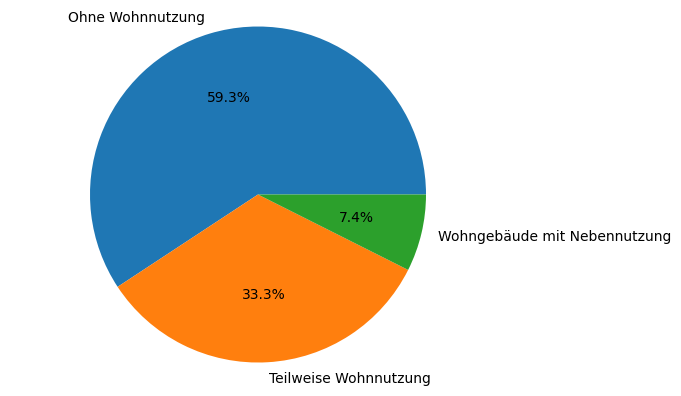

In [14]:
%matplotlib inline
pieFigure, pieAxes = pyplot.subplots()
pieAxes.pie(countGkatCodes,
            labels = ["Ohne Wohnnutzung", "Teilweise Wohnnutzung", "Wohngebäude mit Nebennutzung"],
            autopct="%1.1f%%")
pieAxes.axis("equal")

Als nächstes erzeugen wir durch den Aufruf der Methode `subplots()` am `pyplot`-Objekt ein neues Figure- und ein Axes-Objekt, die jeweils das Diagramm selbst (`pieFigure`) und die Diagramm-Achsen (`pieAxes`) repräsentieren. Am `pieAxes`-Objekt können wir die Methode `pie()` aufrufen, an die wir drei Parameter übergeben. Der erste Parameter sind die aufgezählten Werte der Codes, also das Ergebnis des Vorschrittes, die Variable `countGkatCodes`. Im zweiten Parameter, mit der Bezeichnung `labels`, übergeben wir die Beschriftung der einzelnen Attribute. Hier könnten wir einfach die Code-Werte wiederholen, schöner ist es sicherlich, wenn wir die Code-Werte gleich "übersetzen" und ihre Bedeutung, also "Ohne Wohnnutzung" und "Teilweise Wohnnutzung" mitgeben. Im letzten Parameter `autopct` stilisieren wir die Darstellung der Prozentwerte innerhalb des Tortendiagramms mit der Angabe "%1.1f%%". Die Zahlenwerte geben die Anzahl der (Mindest-)Stellen vor und nach dem Punkt an. In diesem Fall ist eine Vor- und eine Nachpunktstelle definiert.

Als nächstes rufen wir die Methode `axis()` am `pieAxis`-Objekt mit dem Parameterwert "equal" auf. Dies gibt an, dass die beiden (nicht sichtbaren) Achsen des Tortendiagramms gleich skaliert werden sollen. So stellen wir sicher, dass das Diagramm auch als echter Kreis und nicht verzerrt gezeichnet wird.

Es ergibt sich nun also, dass im betrachteten Gebiet von _100 Metern_ um das Zürcher Stadthaus ein Grossteil der Gebäude, nämlich _62.5 %_ keine Wohnnutzung haben und ein kleinerer Teil, nämlich _37.5 %_ eine teilweise Wohnnutzung aufweisen.

## Multivariable Visualisierung

Wir können in einem Notebook aber auch multivariable Visualisierungen umsetzen. Schauen wir uns doch hierzu die beiden Spalten "properties.gbauj", "properties.gastw" und "properties.garea" an. "GBAUJ" kennen wir ja schon bereits und "GAREA" bezeichnet laut MMK 4.1 die Grundrissfläche des Gebäudes, also die Fläche, die den Erdboden überdeckt/versiegelt. In "GASTW" ist die Anzahl der Stockwerke als Ganzzahl enthalten. Im nächsten Schritt erstellen wir eine multivariable Visualisierung, welche diese drei unterschiedliche Merkmale der Gebäude zueinander in Beziehung setzt:

1. **X-Achse**: Das Baujahr des Gebäudes (`properties.gbauj`).
2. **Y-Achse**: Die Anzahl der Geschosse (`properties.gastw`), abgebildet durch die Höhe der Balken.
3. **Farbskala**: Die Grundrissfläche in Quadratmetern (`properties.garea`). Die Farbgebung reicht von Grün (geringe Fläche) bis hin zu Rot (grosse Fläche).

Zunächst müssen wir sicherstellen, dass unsere Datenbasis vollständig ist. Wir filtern daher alle Datensätze heraus, bei denen eines dieser drei Merkmale fehlt. Dies geschieht mithilfe der Methode `dropna()`:

In [15]:
plotData = buildingsDataFrame.dropna(subset=['properties.gbauj', 'properties.garea', 'properties.gastw'])

Um die Gebäudefläche visuell durch Farben darzustellen, definieren wir im nächsten Schritt eine entsprechende Farbskala. Wir nutzen dazu die Bibliothek `matplotlib.colors`. Die Skala wird anhand des minimalen und maximalen Werts der Grundrissfläche (`properties.garea`) normalisiert. Wir wählen die Farbpalette `RdYlGn_r`, die einen fliessenden Übergang von Grün (kleine Fläche) zu Rot (grosse Fläche) bietet:

In [16]:
import matplotlib.colors as mcolors
norm = mcolors.Normalize(vmin=plotData['properties.garea'].min(), vmax=plotData['properties.garea'].max())
cmap = pyplot.get_cmap('RdYlGn_r')

Wir initialisieren nun das Diagramm und zeichnen die grundlegenden Balken. Die x-Achse stellt das Baujahr dar, die y-Achse die Anzahl der Geschosse und die Farbe der Balken wird durch die Grundrissfläche bestimmt:

In [17]:
pyplot.ioff() # permanentes Zeichnen des Diagramms verhindern
fig, ax = pyplot.subplots(figsize=(14, 7))

bars = ax.bar(plotData["properties.gbauj"], 
              plotData["properties.gastw"], 
              color=cmap(norm(plotData["properties.garea"])),
              width=1.8, 
              edgecolor='black', 
              linewidth=0.5,
              alpha=0.85)

Als Nächstes fügen wir die Beschriftungen für die x- und y-Achse sowie eine horizontale Gitterlinie hinzu. Dies erleichtert die Lesbarkeit der einzelnen Datenpunkte erheblich:

In [18]:
ax.set_xlabel('Baujahr', fontsize=12)
ax.set_ylabel('Anzahl Stockwerke', fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.4)

Schliesslich ergänzen wir eine Farbleiste (`colorbar`), welche als Legende für die Flächenangaben dient. Dadurch wird ersichtlich, welcher Farbton welcher Quadratmeterzahl entspricht:

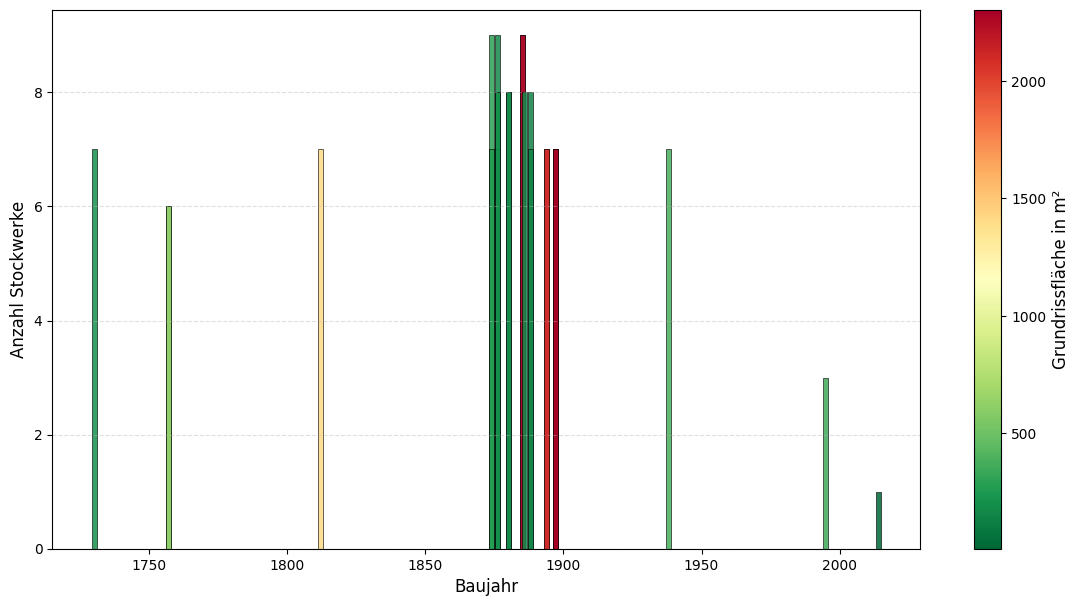

In [19]:
sm = pyplot.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label('Grundrissfläche in m²', fontsize=12)
fig

Das erstellte Diagramm bietet eine kompakte Übersicht zur historischen Entwicklung der Überbauung im untersuchten Areal.

Insbesondere fällt auf, dass am Ende des 19. Jahrhunderts einige sehr voluminöse Gebäude (dargestellt als breite, rote Balken) errichtet wurden. Diese zeichnen sich durch eine Kombination aus hoher Stockwerkzahl und grosser Grundrissfläche aus. Andere Epochen sind wiederum durch kleinere Gebäude oder geringere Überbauungsdichten gekennzeichnet.

## Fazit

Wir haben in diesem kleinen Workshop gesehen, wie sich offene, frei zugängliche Geodaten nutzen lassen, um mit Hilfe von _Jupyter Notebook_ und _pandas_ auf einfache Weise protokollierte, räumliche Analysen auf diesen Daten durchzuführen. Solche Analysen können für jeden Ort der Schweiz umgesetzt werden. Sie können von jedem Bürger, Verwaltungen und Unternehmen vorgenommen werden. Natürlich ist das nur ein einleitendes Beispiel und es ist sicherlich wesentlich mehr aus den verfügbaren Daten herauszuholen als hier aufgezeigt. Das bringt ungeahnte Möglichkeiten und Potenzial für Wachstum und Verbesserung des allgemeinen Wohlstands eines Landes. Es ist daher sehr erfreulich, dass das Bundesamt für Statistik und die swisstopo diesen Weg gehen und solche Daten frei zugänglich bereitstellen. Insbesondere ist die Form der Bereitstellung zu begrüssen, denn die Daten sind äusserst gut maschinenlesbar. Dafür gebührt ihnen aus meiner Sicht grosser Dank. Dies ist leider nicht immer selbstverständlich, in vielen Fällen in denen Daten bereitgestellt werden, geschieht dies leider immer noch in recht obskuren Formaten, wie z.B. geplotteten PDFs. Mit solchen "Daten" lässt sich dann leider nur sehr schwer analytisch arbeiten.

**Übrigens:** Diese Dokumentation, die Sie gerade lesen, dieses Fenster in die Vergangenheit und Zukunft, ist in ihrem Kernbereich selbst kein starrer Text, sondern ein lebendiges, vollständig ausführbares **Jupyter Notebook**.

Viel Freude auf Ihren eigenen Forschungsreisen!